# Comienzo importando las librerias necesarias para realizar la práctica, si bien en NLP la aletoriedad es menor que en redes neuronales es una buena práctica fijar semillas para que el ejercicio sea reproducible y verificable.

In [2]:
# 1. Setup
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import spacy
from wordcloud import WordCloud

# ML
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import PCA

In [3]:
# Clonar tu repositorio en Colab
!git clone https://github.com/Fablop84/NLP_entrega_practica.git

# Cambiar al directorio del repo
%cd NLP_entrega_practica


Cloning into 'NLP_entrega_practica'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 4 (delta 0), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), 2.37 MiB | 8.57 MiB/s, done.
/content/NLP_entrega_practica


In [4]:
# Se visualizan los archivos en el repositorio
!ls

data


In [5]:
# Abro directamente el dataset, al ser un archivo Json de 2.4 MB aproximadamente no tuve necesidad de guardarlo en Google Drive, la data la tengo directamente en el repositorio
#data de Github. El dataset lo escogí porque me gusta la música (los instrumentos) y porque por tamaño era el más manejable.
with open("data/Musical_Instruments_5.json", "r") as f:
    data = [json.loads(line) for line in f]

df_music = pd.DataFrame(data)
df_music.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5.0,good,1393545600,"02 28, 2014"
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5.0,Jake,1363392000,"03 16, 2013"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5.0,It Does The Job Well,1377648000,"08 28, 2013"
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""","[0, 0]",Nice windscreen protects my MXL mic and preven...,5.0,GOOD WINDSCREEN FOR THE MONEY,1392336000,"02 14, 2014"
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,"[0, 0]",This pop filter is great. It looks and perform...,5.0,No more pops when I record my vocals.,1392940800,"02 21, 2014"


# **Análisis Exploratorio**

In [6]:
# Realizo una exploración general del dataset en los siguientes pasos
df_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10261 entries, 0 to 10260
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      10261 non-null  object 
 1   asin            10261 non-null  object 
 2   reviewerName    10234 non-null  object 
 3   helpful         10261 non-null  object 
 4   reviewText      10261 non-null  object 
 5   overall         10261 non-null  float64
 6   summary         10261 non-null  object 
 7   unixReviewTime  10261 non-null  int64  
 8   reviewTime      10261 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 721.6+ KB


Es un dataset relativamente pequeño de 9 columnas y 10261 registros, voy a manejar todos los registros y no hacer ninguna separación o muestra de los registros, seguramente sí eliminaré columnas que considere no aporten al modelo o generen "trampa" como el overall.
Es un dataset sobre calificación y comentarios de instrumentos o equipos músicales. Está en idioma inglés, por lo tanto, habrá que tener stopwords en ese idioma.

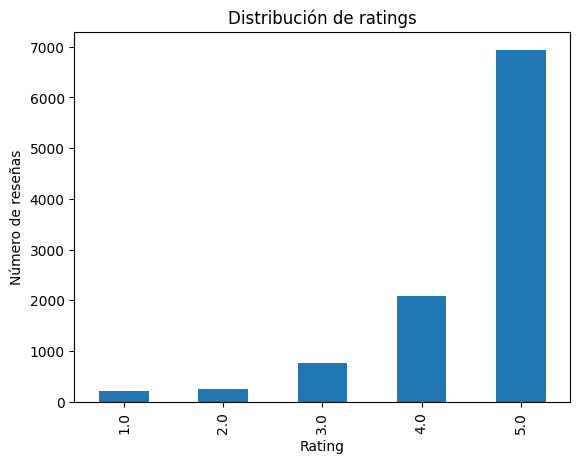

In [7]:
# Distribución de los ratings, apoyandome en la columna overall verificar que tantas reseñas positivas hay. Ayuda a visualizar si el dataset está desbalanceado

df_music['overall'].value_counts().sort_index().plot.bar()
plt.title("Distribución de ratings")
plt.xlabel("Rating")
plt.ylabel("Número de reseñas")
plt.show()

Podemos ver que la mayor parte de calificaciones son positivas

<Axes: >

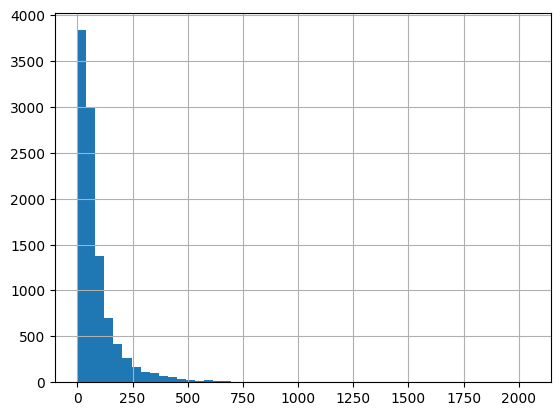

In [8]:
# Ver la longitud de las reseñas
df_music['text_length'] = df_music['reviewText'].apply(lambda x: len(x.split()))
df_music['text_length'].describe()
df_music['text_length'].hist(bins=50)

In [9]:
from collections import Counter
import re

tokens = [re.findall(r'\w+', t.lower()) for t in df_music['reviewText']]
vocab = Counter([tok for sublist in tokens for tok in sublist])
print("Tamaño del vocabulario:", len(vocab))
print("Top 20 palabras más frecuentes:", vocab.most_common(20))

Tamaño del vocabulario: 20587
Top 20 palabras más frecuentes: [('the', 44896), ('i', 32327), ('a', 28092), ('and', 27091), ('it', 24601), ('to', 23161), ('is', 14603), ('of', 13629), ('for', 13303), ('this', 12989), ('you', 10297), ('that', 9911), ('my', 9507), ('on', 9398), ('with', 9199), ('in', 9007), ('but', 7990), ('have', 7164), ('t', 6211), ('s', 6157)]


El top de palabras son stopwords, es evidente que se debe realizar eliminación de éstas.

In [10]:
# N-gramas frecuentes
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vectorizer.fit_transform(df_music['reviewText'])
print(vectorizer.get_feature_names_out())

['and it' 'and the' 'but it' 'easy to' 'for the' 'if you' 'in the' 'it is'
 'of the' 'on my' 'on the' 'the guitar' 'the price' 'they are' 'this is'
 'to be' 'to the' 'to use' 'with the' 'you can']


In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(3,3), max_features=20)
X = vectorizer.fit_transform(df_music['reviewText'])
print(vectorizer.get_feature_names_out())

['and it is' 'as well as' 'but if you' 'easy to use' 'for the money'
 'for the price' 'if you are' 'if you have' 'if you re' 'if you want'
 'it would be' 'one of the' 'one of these' 'out of the' 'some of the'
 'this is great' 'this is the' 'to get the' 'you have to' 'you want to']


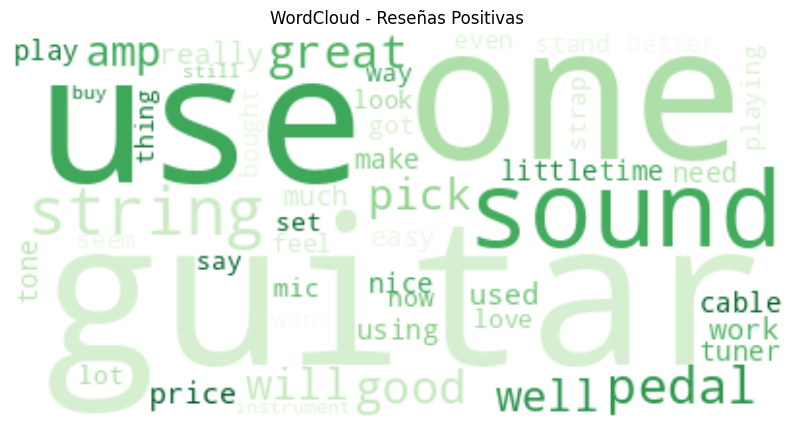

In [12]:
# Wordcloud para revisar las reseñas "positivas" con un overall >= 4
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# Reseñas positivas (ej. rating >= 4)
pos_text = " ".join(df_music[df_music['overall'] >= 4]['reviewText'].astype(str))

wc_pos = WordCloud(
    background_color='white',
    max_words=50,
    colormap='Greens',
    stopwords=STOPWORDS.update(['br','music','album','song'])
).generate(pos_text)

plt.figure(figsize=(10,6))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Reseñas Positivas")
plt.show()


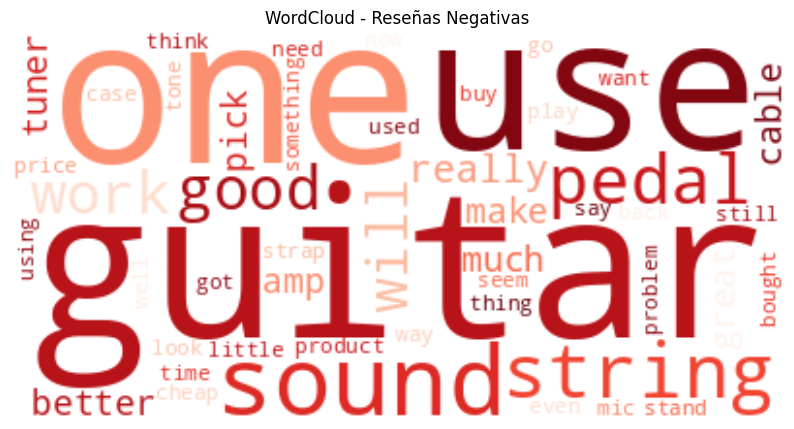

In [13]:
# Wordcloud para revisar las reseñas "negativas" con un overall <= 3
# Reseñas negativas (ej. rating <= 2)
neg_text = " ".join(df_music[df_music['overall'] <= 3]['reviewText'].astype(str))

wc_neg = WordCloud(
    background_color='white',
    max_words=50,
    colormap='Reds',
    stopwords=STOPWORDS.update(['br','music','album','song'])
).generate(neg_text)

plt.figure(figsize=(10,6))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Reseñas Negativas")
plt.show()

Con el análisis de las wordcloud separando las reseñas postivas y negativas no es posible identificar palabras destacadas que sean contundentes o realmente visibles en cuanto a una crítica negativa o una opinión positiva, es decir, el vocabulario de ambos conjuntos es muy general.

# **Preprocesamiento**

In [14]:
# Selección de columnas relevantes
df_music = df_music[['reviewText', 'overall']]

# Verificamos la nueva estructura
df_music.head()

,reviewText,overall
0,"Not much to write about here, but it does exac...",5.0
1,The product does exactly as it should and is q...,5.0
2,The primary job of this device is to block the...,5.0
3,Nice windscreen protects my MXL mic and preven...,5.0
4,This pop filter is great. It looks and perform...,5.0


In [15]:
# Convertir la columna overall en etiquetas de clasificación (postivo/negativo)
def label_classification(row):
    if int(row['overall']) <= 3:
        return 1
    else:
        return 0

In [16]:
df_music['classification_label'] = df_music.apply(lambda row: label_classification(row), axis=1)

In [17]:
df_music.head()

,reviewText,overall,classification_label
0,"Not much to write about here, but it does exac...",5.0,0
1,The product does exactly as it should and is q...,5.0,0
2,The primary job of this device is to block the...,5.0,0
3,Nice windscreen protects my MXL mic and preven...,5.0,0
4,This pop filter is great. It looks and perform...,5.0,0


In [18]:
df_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10261 entries, 0 to 10260
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   reviewText            10261 non-null  object 
 1   overall               10261 non-null  float64
 2   classification_label  10261 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 240.6+ KB


In [19]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Descargar recursos necesarios para procesar inglés
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [20]:
# Cargar la lista estándar
stop_words = set(stopwords.words('english'))

# Lista de palabras de negación que queremos conservar
negations = {'no', 'not', 'neither', 'nor', 'none', 'never', 'isnt', 'wasnt',
             'arent', 'werent', 'dont', 'didnt', 'doesnt', 'havent', 'hasnt',
             'hadnt', 'wont', 'cant', 'couldnt', 'shouldnt'}

# Las removemos de la lista de stopwords (asegurando minúsculas)
stop_words = set([word for word in stop_words if word not in negations])

print(f"¿Se eliminó 'no' de las stopwords?: {'no' not in stop_words}")

¿Se eliminó 'no' de las stopwords?: True


Al ser un análisis de opiniones las negaciones (no y sus semejantes) pueden cambiar el sentido de la oración por completo, por ejemplo, "I don´t like" es diferente a "I like", por lo tanto, excluyo de las stopwords palabras con negación.

In [21]:
# Se define la función limpiadora
def preprocess_text_safe(text):
    # 1. Todo a minúsculas primero para que coincida con la lista 'negations'
    text = str(text).lower()

    # 2. Reemplazar contracciones comunes manualmente para evitar que el Regex las rompa
    # Ejemplo: don't -> dont
    text = text.replace("n't", " nt").replace("can't", "cant")

    # 3. Limpiar caracteres especiales (manteniendo espacios)
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenizar
    tokens = text.split()

    # 5. Filtrar y Lematizar (Aquí 'not' y 'no' se mantendrán)
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return " ".join(cleaned_tokens)


In [22]:
# Aplico la transformación al dataframe

# Aplica la función y creamos 'review_cleaned'
df_music['review_cleaned'] = df_music['reviewText'].apply(preprocess_text_safe)

# Revisión de los primeros resultados
print(f"Prueba: {preprocess_text_safe('Not much to write about, it is not bad')}")
# Debería devolver: "not much write not bad"


Prueba: not much write not bad


In [23]:
print(df_music[['reviewText', 'review_cleaned']].head())

                                          reviewText  \
0  Not much to write about here, but it does exac...   
1  The product does exactly as it should and is q...   
2  The primary job of this device is to block the...   
3  Nice windscreen protects my MXL mic and preven...   
4  This pop filter is great. It looks and perform...   

                                      review_cleaned  
0  not much write exactly supposed filter pop sou...  
1  product exactly quite affordablei not realized...  
2  primary job device block breath would otherwis...  
3  nice windscreen protects mxl mic prevents pop ...  
4  pop filter great look performs like studio fil...  


Distribución de clases:
classification_label
0    9022
1    1239
Name: count, dtype: int64

Porcentaje:
classification_label
0    87.925153
1    12.074847
Name: proportion, dtype: float64


/tmp/ipython-input-1476367239.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='classification_label', data=df_music, palette='viridis')


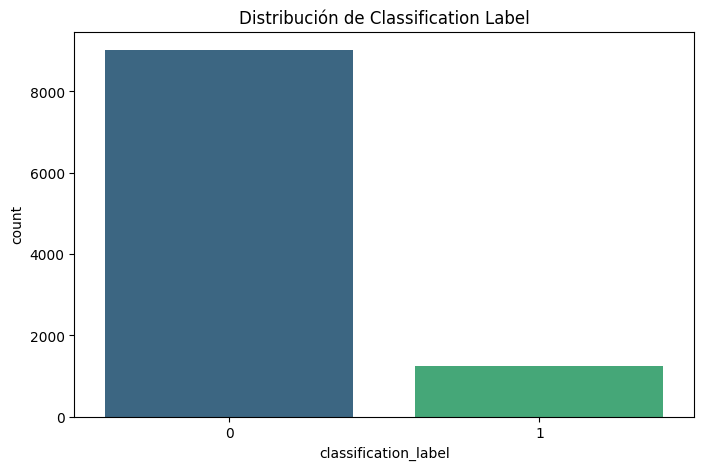

In [24]:
# reviso de nuevo el balanceo del dataset con la columna classification_label
import matplotlib.pyplot as plt
import seaborn as sns

# Conteo exacto de cada clase
print("Distribución de clases:")
print(df_music['classification_label'].value_counts())

# Porcentaje de cada clase
print("\nPorcentaje:")
print(df_music['classification_label'].value_counts(normalize=True) * 100)

# Gráfico de barras
plt.figure(figsize=(8, 5))
sns.countplot(x='classification_label', data=df_music, palette='viridis')
plt.title('Distribución de Classification Label')
plt.show()


Ajuste la clasificación para que no estuviera tan desbalanceado el dataframe, cambie el rango a <=3 -> 1 (calificaciones 1,2 y3); >3 -> 0 (calificaciones 4 y 5). Antes estaba "<3". Este ajuste paso de una distribución 95.5% - 4.5% a 88% - 12% aún desbalanceado pero más manejable para el modelo.
Estuve revisando y hay varias técnicas para mejorar el balanceo y las predicciones. Seguramente utilice Undersampling para reducir las muestras de la clase (0), pero lo haré más adelante, seguiré con este dataset así para luego comparar resultados.   

In [25]:
# Genero nuevamente el vocabulario después de la limpieza para ver cómo cambia con el original
from collections import Counter

# 1. Tokenizar el texto ya limpio (que ya está en minúsculas y sin caracteres especiales)
tokens_cleaned = [t.split() for t in df_music['review_cleaned']]

# 2. Generar el nuevo vocabulario
vocab_cleaned = Counter([tok for sublist in tokens_cleaned for tok in sublist])

print("--- COMPARATIVA DE VOCABULARIO ---")
print(f"Tamaño vocabulario original: {len(vocab)}")
print(f"Tamaño vocabulario limpio:   {len(vocab_cleaned)}")
print(f"Reducción de dimensiones:    {((len(vocab) - len(vocab_cleaned)) / len(vocab) * 100):.2f}%")

print("\n--- TOP 20 PALABRAS (POST-PROCESAMIENTO) ---")
# Aquí deberías ver palabras con significado musical y tus negaciones ("not", "no")
print(vocab_cleaned.most_common(20))


--- COMPARATIVA DE VOCABULARIO ---
Tamaño vocabulario original: 20587
Tamaño vocabulario limpio:   26794
Reducción de dimensiones:    -30.15%

--- TOP 20 PALABRAS (POST-PROCESAMIENTO) ---
[('guitar', 6666), ('nt', 6155), ('not', 5736), ('one', 4761), ('sound', 4571), ('string', 4570), ('great', 3981), ('like', 3934), ('use', 3714), ('good', 3686), ('pedal', 3594), ('work', 3063), ('well', 3023), ('get', 2928), ('would', 2588), ('amp', 2360), ('no', 2230), ('really', 2228), ('pick', 2217), ('price', 2192)]


Quise hacer el ejercicio de comparar los dos vocabularios, teóricamente el vocabulario procesado debería disminuir porque se eliminan stopwords. En la limpieza anterior se utiliaron split simple para tokenizar (puede que no haya sido muy preciso), al aumentar el tamaño del vocabulario procesado se evidencia que algo no quedó bien. Voy a crear una nueva función de limpieza más robusta con el tokenizador de NLTK y un lemmatizador de SpaCy.

In [26]:
import nltk

# Descargar recursos por si acaso
nltk.download('punkt_tab')

# Por si acaso, para evitar errores futuros
nltk.download('punkt')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [27]:
import spacy
from nltk.tokenize import word_tokenize

# Cargar el motor de SpaCy (se desactivan cosas no necesarias para ganar velocidad)
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

# Se revisan las negaciones fuera de las stopwords como hicimos antes
stop_words = set(stopwords.words('english'))
negations = {'no', 'not', 'n\'t', 'cant', 'dont', 'didnt', 'never', 'neither', 'nor', 'none', 'never', 'isnt', 'wasnt',
             'arent', 'werent', 'dont', 'didnt', 'doesnt', 'havent', 'hasnt',
             'hadnt', 'wont', 'cant', 'couldnt', 'shouldnt'}
stop_words = stop_words - negations


In [28]:
# Función de limpieza híbrida por la combinación de NLTK y SpaCy

def preprocess_hybrid(text):
    # 1. Limpieza básica y minúsculas
    text = str(text).lower()

    # IMPORTANTE: Reemplazamos el apóstrofe por espacio para que NLTK no se confunda
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 2. Tokenizador de NLTK
    tokens = word_tokenize(text)

    # 3. Unimos temporalmente para que SpaCy analice el contexto
    doc = nlp(" ".join(tokens))

    # 4. Lematización de SpaCy + Filtro de Stopwords
    # spacy usa .lemma_ para devolver la raíz
    cleaned_tokens = [token.lemma_ for token in doc if token.text not in stop_words]

    return " ".join(cleaned_tokens)

# Aplicamos la nueva lógica
df_music['review_cleaned'] = df_music['reviewText'].apply(preprocess_hybrid)


In [29]:
from collections import Counter

# 1. Obtener tokens del texto original (para comparar)
tokens_orig = [re.findall(r'\w+', t.lower()) for t in df_music['reviewText']]
vocab_orig = Counter([tok for sublist in tokens_orig for tok in sublist])

# 2. Obtener tokens del nuevo texto procesado con SpaCy
# Usamos .split() porque el texto ya está limpio y unido por espacios
tokens_hyb = [t.split() for t in df_music['review_cleaned']]
vocab_hyb = Counter([tok for sublist in tokens_hyb for tok in sublist])

# 3. Mostrar métricas de éxito
print("--- RESULTADOS DEL PROCESAMIENTO HÍBRIDO ---")
print(f"Vocabulario Original: {len(vocab_orig)} palabras")
print(f"Vocabulario Híbrido:  {len(vocab_hyb)} palabras")

reduccion = (1 - len(vocab_hyb) / len(vocab_orig)) * 100
print(f"Porcentaje de reducción: {reduccion:.2f}%")

print("\n--- TOP 20 PALABRAS (HÍBRIDO) ---")
print(vocab_hyb.most_common(20))


--- RESULTADOS DEL PROCESAMIENTO HÍBRIDO ---
Vocabulario Original: 20587 palabras
Vocabulario Híbrido:  14907 palabras
Porcentaje de reducción: 27.59%

--- TOP 20 PALABRAS (HÍBRIDO) ---
[('use', 7112), ('guitar', 6816), ('not', 6413), ('sound', 5162), ('well', 5052), ('one', 4944), ('string', 4818), ('good', 4683), ('get', 4604), ('like', 4193), ('great', 4181), ('pedal', 3677), ('work', 3630), ('make', 3091), ('buy', 2933), ('play', 2742), ('amp', 2515), ('pick', 2479), ('price', 2427), ('would', 2397)]


Con esta función híbrida más robusta y si se quiere llamar más profesional se logra reducir el vocabulario en 27.59% lo cual tiene sentido e indica que los procesos de limpieza y lemmatización funcionaron correctamente.

# **Modelado**

Separamos los conjuntos de Train (80%) y Test (20%)

In [30]:
X = df_music['review_cleaned']
y = df_music['classification_label']

# Usamos SEED para asegurar que la partición sea siempre la misma
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")


Entrenamiento: 8208 muestras
Prueba: 2053 muestras


Extracción de features

In [31]:
# Vectorización
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),   # Capturamos contextos más ricos
    max_df=0.95,          # Eliminamos lo que es demasiado obvio
    min_df=3,             # Eliminamos ruidos y typos que aparecen < 3 veces
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Dimensiones de la matriz: {X_train_tfidf.shape}")


Dimensiones de la matriz: (8208, 5000)


Análisis de Chi Cuadrado

<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:29: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:29: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-2669352327.py:27: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$\chi^2$ Score', fontsize=18)
/tmp/ipython-input-2669352327.py:29: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f'Top {n_top} palabras más informativas ($\chi^2$)', fontsize=20)


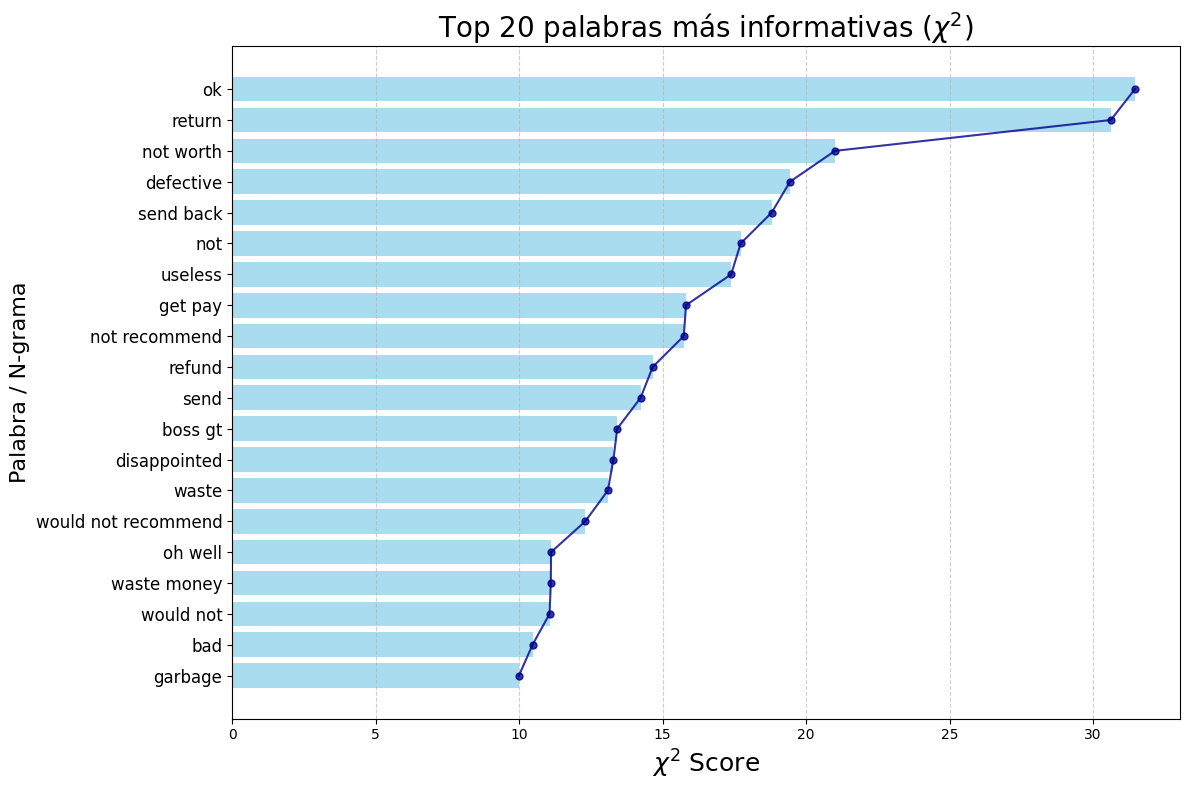

In [32]:
from sklearn.feature_selection import chi2

# 1. Parámetros de visualización
n_top = 20  # Aumentamos un poco para ver más contexto

# 2. Calcular los puntajes Chi-cuadrado
# chi2 devuelve (puntajes, p-values)
chi2score = chi2(X_train_tfidf, y_train)[0]

# 3. Mapear puntajes con los nombres de las palabras (features)
scores = list(zip(vectorizer.get_feature_names_out(), chi2score))

# 4. Ordenar de menor a mayor para sacar el top al final
sorted_scores = sorted(scores, key=lambda x: x[1])
top_chi2 = list(zip(*sorted_scores[-n_top:]))

# 5. Visualización
x_pos = range(len(top_chi2[1]))
labels = top_chi2[0]

plt.figure(figsize=(12, 8))
plt.barh(x_pos, top_chi2[1], align='center', color='skyblue', alpha=0.7)
plt.plot(top_chi2[1], x_pos, '-o', markersize=5, color='darkblue', alpha=0.8)
plt.yticks(x_pos, labels, fontsize=12)

# Usamos LaTeX para el símbolo de Chi-cuadrado
plt.xlabel('$\chi^2$ Score', fontsize=18)
plt.ylabel('Palabra / N-grama', fontsize=16)
plt.title(f'Top {n_top} palabras más informativas ($\chi^2$)', fontsize=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Este análisis es revelador y demuestra bastante bien varios aspectos, el modelo tiene señales para poder distinguir las clases. Valió la pena rescatar las negaciones de manera más amplia y no un simple not; el haber utilizado tri gramas ayuda a rescatar este tipo de "sentiemientos" (would not recommend); se evidencian palabras muy declarativas que denotan opiniones negativas: "garbage", "useless", "waste", "dissapointed".

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Instanciar el modelo con tu SEED
model_desbalanceado = LogisticRegression(max_iter=1000, random_state=SEED)

# 2. Entrenar con los datos TF-IDF que acabas de crear
model_desbalanceado.fit(X_train_tfidf, y_train)

# 3. Realizar predicciones sobre el set de prueba
y_pred_base = model_desbalanceado.predict(X_test_tfidf)

# 4. Mostrar el reporte de métricas
print("--- REPORTE DE CLASIFICACIÓN (MODELO DESBALANCEADO) ---")
print(classification_report(y_test, y_pred_base))


--- REPORTE DE CLASIFICACIÓN (MODELO DESBALANCEADO) ---
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1805
           1       0.89      0.06      0.12       248

    accuracy                           0.89      2053
   macro avg       0.89      0.53      0.53      2053
weighted avg       0.89      0.89      0.84      2053



La mátriz de confusión es muy poderosa ya que nos brinda diferente información sobre las clases. Si bien el accuracy es bastante bueno 89%, el recall de la clase 1 (<=3) es demasiado pobre 6%, esto era previsible por el desbalanciamiento del modelo. El modelo no es capaz de detectar sentiemientos negativos.
Curiosamente la precisión de la clase 1 es alta, lo que significa que con las palabras obvias o declarativas las puede identificar y clasificar la reseña correctamente.

# Balancear el modelo con Undersampling

Como lo mencione líneas arriba el modelo y el dataframe en sí están desbalanceados 88% reseñas posotivas 12% reseñas negativas, con los resultados recien vistos es necesario balancear el modelo, volver a entrenar y ver las diferencias con el modelo desbalanceado.

In [34]:
from sklearn.utils import resample
import numpy as np

# 1. Identificamos los índices de cada clase en el set de ENTRENAMIENTO
indices_0 = np.where(y_train == 0)[0]
indices_1 = np.where(y_train == 1)[0]

# 2. Aplicamos Undersampling a los índices de la clase mayoritaria (0)
indices_0_downsampled = resample(indices_0,
                                 replace=False,
                                 n_samples=len(indices_1), # Igualamos al número de negativos
                                 random_state=SEED)

# 3. Combinamos los índices balanceados
indices_balanced = np.concatenate([indices_0_downsampled, indices_1])

# 4. Creamos los nuevos sets de entrenamiento usando estos índices
# (Mantenemos el formato de matriz dispersa para que no falle el número de features)
X_train_bal = X_train_tfidf[indices_balanced]
y_train_bal = y_train.iloc[indices_balanced]

# 5. Entrenar el nuevo modelo balanceado
model_balanced = LogisticRegression(max_iter=1000, random_state=SEED)
model_balanced.fit(X_train_bal, y_train_bal)

# 6. Predecir sobre el set de prueba original (X_test_tfidf)
y_pred_bal = model_balanced.predict(X_test_tfidf)

print("--- REPORTE: MODELO BALANCEADO (UNDERSAMPLING) ---")
print(classification_report(y_test, y_pred_bal))


--- REPORTE: MODELO BALANCEADO (UNDERSAMPLING) ---
              precision    recall  f1-score   support

           0       0.96      0.73      0.83      1805
           1       0.28      0.76      0.41       248

    accuracy                           0.74      2053
   macro avg       0.62      0.75      0.62      2053
weighted avg       0.88      0.74      0.78      2053



Se evidencia la mejora en el recall 76% y por ende en el f1-score, el modelo pasó de ignorar o no detectar las quejas, a un identificador del 76% de usuarios insatisfechos. La reducción de la precisión se debe a que el modelo ahora es más sensible por tener la misma cantidad de muestras positivas y negativas, ante cualquier duda o palabra negativa la tiene a clasificar como negativa (1) y pueden ser reseñas positivas (por eso la precisióbn disminuye)

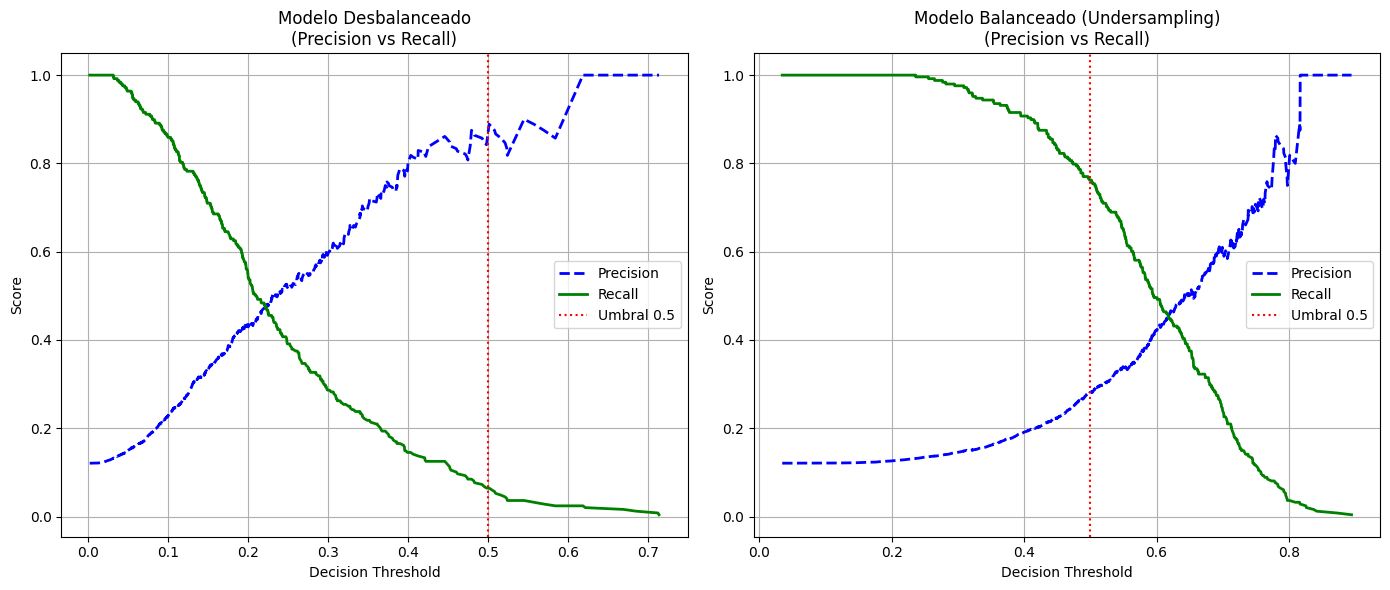

In [35]:
from sklearn.metrics import precision_recall_curve

def plot_combined_pr_threshold(m_base, m_bal, X_test, y_test):
    # 1. Obtener probabilidades para la clase 1 (Negativa)
    probs_base = m_base.predict_proba(X_test)[:, 1]
    probs_bal = m_bal.predict_proba(X_test)[:, 1]

    # 2. Calcular precisiones y recalls para ambos
    p_base, r_base, t_base = precision_recall_curve(y_test, probs_base)
    p_bal, r_bal, t_bal = precision_recall_curve(y_test, probs_bal)

    # 3. Graficar
    plt.figure(figsize=(14, 6))

    # Gráfico 1: Modelo Desbalanceado
    plt.subplot(1, 2, 1)
    plt.plot(t_base, p_base[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(t_base, r_base[:-1], "g-", label="Recall", linewidth=2)
    plt.axvline(x=0.5, color='red', linestyle=':', label='Umbral 0.5')
    plt.title("Modelo Desbalanceado\n(Precision vs Recall)")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)

    # Gráfico 2: Modelo Balanceado
    plt.subplot(1, 2, 2)
    plt.plot(t_bal, p_bal[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(t_bal, r_bal[:-1], "g-", label="Recall", linewidth=2)
    plt.axvline(x=0.5, color='red', linestyle=':', label='Umbral 0.5')
    plt.title("Modelo Balanceado (Undersampling)\n(Precision vs Recall)")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Llamada a la función con TUS variables
plot_combined_pr_threshold(model_desbalanceado, model_balanced, X_test_tfidf, y_test)


Analizando la gráfica vemos como en el modelo desbalanceado el recall cae en picada mucho antes del llegar al umbral de 0.5, lo que significa que el modelo no se atreve a marcar nada como negativo.
En el modelo balanceado las curvas son más estables y se ruzan en un punto por encima del umbral lo que demuestra que el Undersampling le dio "poder" al modelo para identificar la clase minoritaria, igual indica un modelo más robusto.  

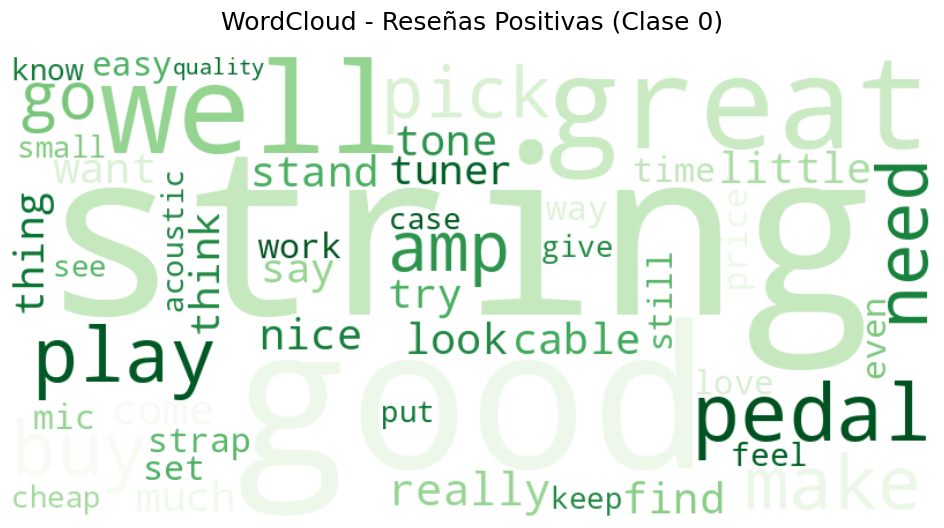

In [36]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1. Definir palabras que queremos ignorar (ruido temático)
extra_stops = {'br', 'music', 'album', 'song', 'one', 'get', 'use', 'sound', 'guitar', 'instrument'}
current_stopwords = STOPWORDS.union(extra_stops)

# 2. Filtrar y unir el texto limpio de la clase 0
pos_text = " ".join(df_music[df_music['classification_label'] == 0]['review_cleaned'].astype(str))

# 3. Generar la nube
wc_pos = WordCloud(
    background_color='white',
    max_words=50,
    colormap='Greens',
    stopwords=current_stopwords,
    width=800,
    height=400
).generate(pos_text)

# 4. Mostrar
plt.figure(figsize=(12, 6))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Reseñas Positivas (Clase 0)", fontsize=18, pad=20)
plt.show()


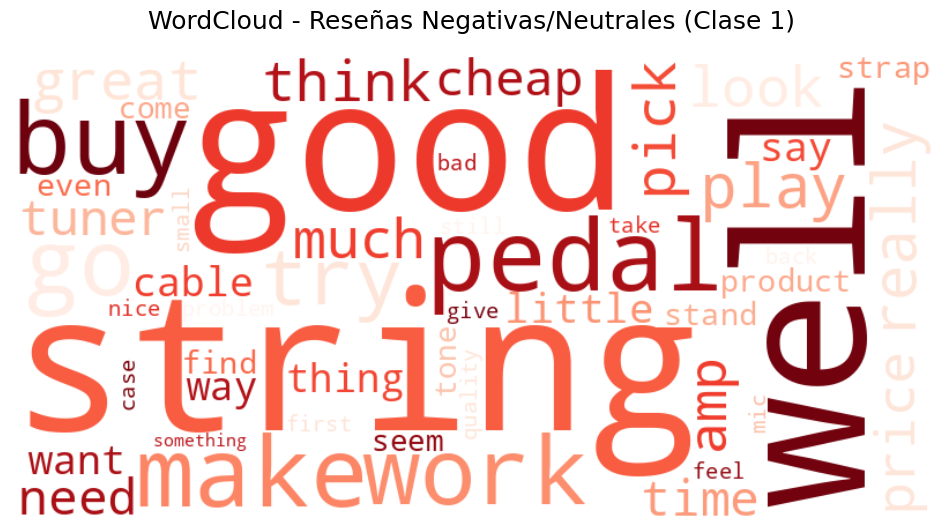

In [37]:
# 1. Filtrar y unir el texto limpio de la clase 1
neg_text = " ".join(df_music[df_music['classification_label'] == 1]['review_cleaned'].astype(str))

# 2. Generar la nube (usando tonos rojos para distinguir)
wc_neg = WordCloud(
    background_color='white',
    max_words=50,
    colormap='Reds',
    stopwords=current_stopwords,
    width=800,
    height=400
).generate(neg_text)

# 3. Mostrar
plt.figure(figsize=(12, 6))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Reseñas Negativas/Neutrales (Clase 1)", fontsize=18, pad=20)
plt.show()


Pese a que se realizó limpieza y reducción del vocabulario se observa que existen muchas palabras comunes entre ambas clases, no son realmente diferenciables palabras obvias o evidentes a simple vista.

# **Predict**

Realizo unas pruebas con reseñas para probar cómo está trabajando el modelo

In [38]:
import random

def predict_review_sentiment(review_index, model, vectorizer):
    # 1. Obtener los datos reales
    original_text = df_music.iloc[review_index]['reviewText']
    actual_label = df_music.iloc[review_index]['classification_label']

    # 2. Preprocesar el texto (Usamos tu función híbrida de ayer)
    # Esto asegura que el texto se limpie igual que el entrenamiento
    cleaned_text = preprocess_hybrid(original_text)

    # 3. Vectorizar y Predecir
    # Transformamos el texto limpio a la matriz TF-IDF
    vectorized_text = vectorizer.transform([cleaned_text])
    prediction = model.predict(vectorized_text)[0]

    # 4. Mapear etiquetas para que sea más legible
    label_map = {0: "Positivo (0)", 1: "Negativo/Neutral (1)"}

    # 5. Mostrar resultados
    print(f"Review no. {review_index}")
    print(f"Texto original: {original_text[:150]}...") # Mostramos solo el inicio
    print(f"Sentimiento REAL: {label_map[actual_label]}")
    print(f"Predicción MODELO: {label_map[prediction]}")

    # Verificación de éxito
    if actual_label == prediction:
        print("✅ ¡Acierto!")
    else:
        print("❌ Fallo")
    print("-" * 30)

# Ejecutar para 5 muestras aleatorias de TODO el dataframe
print("--- PRUEBA DE PREDICCIÓN ALEATORIA ---\n")
samples = random.sample(range(0, len(df_music)), 5)
for i in samples:
    predict_review_sentiment(i, model_balanced, vectorizer)


--- PRUEBA DE PREDICCIÓN ALEATORIA ---

Review no. 1824
Texto original: D'Addario guitar strings are favourite strings.  They last a little longer and always sound good on my Ovation guitars and also or my other acoustic g...
Sentimiento REAL: Positivo (0)
Predicción MODELO: Positivo (0)
✅ ¡Acierto!
------------------------------
Review no. 409
Texto original: This is a distortion pedal. It will give your amp a boost for solos and turn a clean amp into a dirty girl. It's pretty harsh in tone - kind of a whit...
Sentimiento REAL: Positivo (0)
Predicción MODELO: Positivo (0)
✅ ¡Acierto!
------------------------------
Review no. 4506
Texto original: Nice bright and full sound. Good life, they sound good for a couple of months. Inexpensive. Fast delivery. I am happy with this product....
Sentimiento REAL: Positivo (0)
Predicción MODELO: Positivo (0)
✅ ¡Acierto!
------------------------------
Review no. 4012
Texto original: Very nice quality, inexpensive guitar strap. A little tough to get 

Inserto dos reseñas que yo mismo hice para ver cómo fuciona el modelo

In [39]:
mi_resena = "This pedal sounds great, I will spend my money there!" #Inserta o edita una reseña positiva o negativa
clean_test = preprocess_hybrid(mi_resena)
pred = model_balanced.predict(vectorizer.transform([clean_test]))[0]

print(f"Reseña: {mi_resena}")
print(f"Predicción: {'Negativo' if pred == 1 else 'Positivo'}")


Reseña: This pedal sounds great, I will spend my money there!
Predicción: Positivo


In [40]:
mi_resena = "This pedal sounds like trash, I want my money back!" #Inserta o edita una reseña positiva o negativa
clean_test = preprocess_hybrid(mi_resena)
pred = model_balanced.predict(vectorizer.transform([clean_test]))[0]

print(f"Reseña: {mi_resena}")
print(f"Predicción: {'Negativo' if pred == 1 else 'Positivo'}")


Reseña: This pedal sounds like trash, I want my money back!
Predicción: Negativo


Vamos a probar con herramientas más poderososa de ML, se realizará sobre los datos crudos sin haber corregido el desbalanceo con Undersampling. Vamos a utilizar Random Forest en vez de Regresión Logística.

In [41]:
from sklearn.ensemble import RandomForestClassifier

# 1. Instanciar (Usamos 100 árboles para empezar)
# class_weight='balanced' ajusta los pesos automáticamente al 12% de la clase 1
rf_model = RandomForestClassifier(n_estimators=100,
                                  random_state=SEED,
                                  class_weight='balanced',
                                  n_jobs=-1) # Usa todos tus procesadores

# 2. Entrenar (Usamos los datos originales X_train_tfidf, sin el undersampling manual)
rf_model.fit(X_train_tfidf, y_train)

# 3. Predecir y Evaluar
y_pred_rf = rf_model.predict(X_test_tfidf)

print("--- REPORTE: RANDOM FOREST (CON CLASS WEIGHT) ---")
print(classification_report(y_test, y_pred_rf))


--- REPORTE: RANDOM FOREST (CON CLASS WEIGHT) ---
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      1805
           1       0.89      0.03      0.06       248

    accuracy                           0.88      2053
   macro avg       0.89      0.52      0.50      2053
weighted avg       0.88      0.88      0.83      2053



El Random Forest entrego unos datos incluso peores que el modelo inicial desbalanceado, esto se puede deber a varios factores: Las matrices ITIDF rellenan de ceros, los árboles de decisión prefieren datos númericos continuos y no ceros.
La clase 0 que es la mayoritaria termina por opacar la clase minoritaria

Utilizando Random Forest con el modelo balanceado (Undersampling)

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Instanciar el modelo (Quitamos class_weight porque ya balanceamos los datos manualmente)
rf_balanced = RandomForestClassifier(n_estimators=100,
                                     random_state=SEED,
                                     n_jobs=-1)

# 2. Entrenar con los datos del Undersampling (X_train_bal ya tiene 50/50 de cada clase)
rf_balanced.fit(X_train_bal, y_train_bal)

# 3. Predecir sobre el set de prueba original (X_test_tfidf)
y_pred_rf_bal = rf_balanced.predict(X_test_tfidf)

# 4. Evaluación
print("--- REPORTE: RANDOM FOREST (CON UNDERSAMPLING) ---")
print(classification_report(y_test, y_pred_rf_bal))


--- REPORTE: RANDOM FOREST (CON UNDERSAMPLING) ---
              precision    recall  f1-score   support

           0       0.95      0.69      0.80      1805
           1       0.25      0.75      0.38       248

    accuracy                           0.70      2053
   macro avg       0.60      0.72      0.59      2053
weighted avg       0.87      0.70      0.75      2053



Random Forest mejora con el modelo balanceado pero no está muy lejos del mejor resultado con regresión logística.

# Deep **Learning**

Ahora voy a replicar el modelo al estilo IMDB (Secuencias + Embedding + LSTM) aplicado a mi dataframe original df_music con las columnas review_cleaned y classification_label

Importaciones iniciales necesarias de TensorFlow y Keras

In [66]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import numpy as np

# Usamos SEED para reproducibilidad
SEED = SEED
vocabulary_size = 5000
max_words_len = 100 # Longitud de la secuencia


Convertir texto a secuencias (IDs)

In [67]:
# 1. Crear el Tokenizer (el diccionario word2id)
tokenizer = Tokenizer(num_words=vocabulary_size)
tokenizer.fit_on_texts(df_music['review_cleaned'])

# 2. Convertir texto a secuencias de enteros
sequences = tokenizer.texts_to_sequences(df_music['review_cleaned'])

# 3. Aplicar Padding (para que todas midan lo mismo)
X_pad = pad_sequences(sequences, maxlen=max_words_len)
y = df_music['classification_label'].values

# 4. Dividir en Entrenamiento y Prueba
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Dataset listo: {X_train_dl.shape[0]} muestras de entrenamiento")


Dataset listo: 8208 muestras de entrenamiento


Cálculo de pesos (para manejar el desbalanceo)
Como el dataframe está desbalanceado, se le indica al modelo que la clase minoritaria es la más importante.

In [68]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_dl),
    y=y_train_dl
)
class_weights_dict = dict(enumerate(weights))
print("Pesos de clase:", class_weights_dict)


Pesos de clase: {0: np.float64(0.5686573368435638), 1: np.float64(4.1412714429868815)}


Se define la arquitectura del modelo al estilo IMDB

In [69]:
embedding_size = 32

model_imdb = Sequential([
    Input(shape=(max_words_len,)),
    Embedding(input_dim=vocabulary_size, output_dim=embedding_size),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2), # Capa con memoria
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Salida de probabilidad
])

model_imdb.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

model_imdb.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,945 (730.25 KB)

 Trainable params: 186,945 (730.25 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento

In [71]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_imdb = model_imdb.fit(
    X_train_dl, y_train_dl,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 42s 363ms/step - accuracy: 0.8970 - loss: 0.2340 - recall_4: 0.9354 - val_accuracy: 0.8051 - val_loss: 0.5376 - val_recall_4: 0.5106
Epoch 2/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 78s 333ms/step - accuracy: 0.9277 - loss: 0.1790 - recall_4: 0.9534 - val_accuracy: 0.8149 - val_loss: 0.5962 - val_recall_4: 0.4149
Epoch 3/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 39s 336ms/step - accuracy: 0.9396 - loss: 0.1506 - recall_4: 0.9639 - val_accuracy: 0.8124 - val_loss: 0.6935 - val_recall_4: 0.4681
Epoch 4/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 39s 335ms/step - accuracy: 0.9454 - loss: 0.1384 - recall_4: 0.9668 - val_accuracy: 0.7942 - val_loss: 0.7173 - val_recall_4: 0.4681


Evaluación del modelo

In [72]:
from sklearn.metrics import classification_report

y_probs_dl = model_imdb.predict(X_test_dl)
y_pred_dl = (y_probs_dl > 0.5).astype(int)

print("--- REPORTE FINAL: MODELO LSTM (ESTILO IMDB) ---")
print(classification_report(y_test_dl, y_pred_dl))


65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step
--- REPORTE FINAL: MODELO LSTM (ESTILO IMDB) ---
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1805
           1       0.28      0.50      0.35       248

    accuracy                           0.78      2053
   macro avg       0.60      0.66      0.61      2053
weighted avg       0.84      0.78      0.81      2053



Si bien el f1-score es un poco peor que el modelo de regresión logística (0.41) este modelo tiene un poco más de equilibrio. El recall es del 50% y la precisión del 28%, la cual no es posible mejorar y se podría decir que es el punto debil. Al parecer se llega a un techo de predicción del 0.40, si se desea subir se necesitan más datos (tenemos 10k muy desbalanceados) o tal vez utilizar modelo como BERT.
Yo concluyó que el desbalanceo del dataframe y por ende del modelo afectan demasiado la clase minoritaria, cuando se ajusto con Undersampling los resultados mejoraron, pero al parecer se llega a un límite y para mejorarlos más no hay soluciones inmediatas que puedan hacerlo, habría que utilizar otros métodos y no hay certeza de que tanto puedan mejorar.
Otro aspecto es que en este caso las reseñas como tal pueden confundir al modelo, por ejemplo, "This guitar is bad ass" es una reseña positiva, pero al tener palabras negativas puede ser confuso para el modelo.